1) Take an image as input data and perform the following steps:  

i. Resize your image (gray scale) into a square matrix (if no. of rows and columns are unequal)   
ii. Divide the image into 4 blocks. Show each block into a subplot.  
iii. Apply Median, Average, Laplacian and Sobel filters on each block respectively.  
iv. Display all the processed blocks in a subplot.

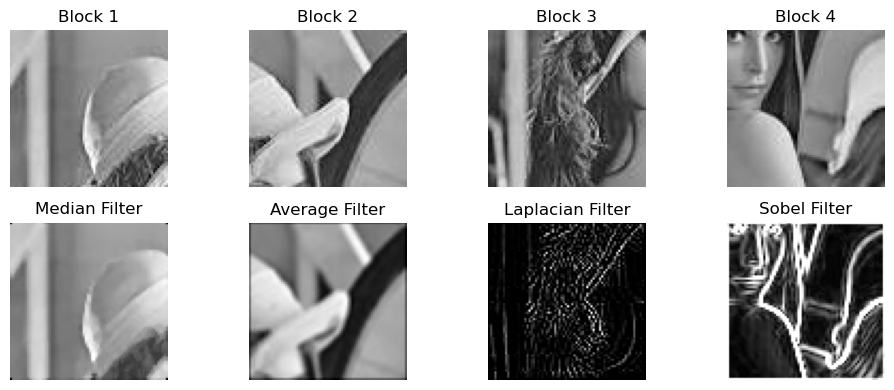

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def resize_to_square(image):
    rows, cols = image.shape
    size = min(rows, cols)
    return image[:size, :size]

def divide_into_blocks(image):
    h, w = image.shape
    h2, w2 = h // 2, w // 2
    return [
        image[0:h2, 0:w2],
        image[0:h2, w2:w],
        image[h2:h, 0:w2],
        image[h2:h, w2:w]
    ]

def apply_median_filter(block, size=3):
    pad = size // 2

    rows, cols = block.shape
    padded = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded[pad:pad+rows, pad:pad+cols] = block

    result = np.zeros_like(block)
    for i in range(rows):
        for j in range(cols):
            window = padded[i:i+size, j:j+size]
            result[i, j] = np.median(window)
    return result

def apply_average_filter(block, size=3):
    pad = size // 2
    
    rows, cols = block.shape
    padded = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded[pad:pad+rows, pad:pad+cols] = block

    result = np.zeros_like(block)
    for i in range(rows):
        for j in range(cols):
            window = padded[i:i+size, j:j+size]
            result[i, j] = np.sum(window) / (size * size)
    return result

def apply_laplacian_filter(block):
    mask = np.array([[0, 1, 0],
                     [1, -4, 1],
                     [0, 1, 0]])
    pad = 1
    
    rows, cols = block.shape
    padded = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded[pad:pad+rows, pad:pad+cols] = block
    
    result = np.zeros_like(block)
    for i in range(rows):
        for j in range(cols):
            window = padded[i:i+3, j:j+3]
            result[i, j] = np.sum(window * mask)
    return np.clip(result, 0, 255)

def apply_sobel_filter(block):
    gx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
    gy = np.array([[-1, -2, -1],
                   [0, 0, 0],
                   [1, 2, 1]])
    pad = 1
    
    rows, cols = block.shape
    padded = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded[pad:pad+rows, pad:pad+cols] = block
    
    result = np.zeros_like(block)
    for i in range(rows):
        for j in range(cols):
            window = padded[i:i+3, j:j+3]
            gx_val = np.sum(window * gx)
            gy_val = np.sum(window * gy)
            result[i, j] = np.sqrt(gx_val**2 + gy_val**2)
    return np.clip(result, 0, 255)

def main():
    img = cv2.imread("D:\\Code\\lenna.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float32)
    img = resize_to_square(img)

    blocks = divide_into_blocks(img)

    plt.figure(figsize=(10, 4))

    for i in range(4):
        plt.subplot(2, 4, i + 1)
        plt.imshow(blocks[i], cmap='gray')
        plt.title(f"Block {i + 1}")
        plt.axis('off')

    processed_blocks = [apply_median_filter(blocks[0]), 
                 apply_average_filter(blocks[1]), 
                 apply_laplacian_filter(blocks[2]), 
                 apply_sobel_filter(blocks[3])]
    
    filter_titles = ["Median Filter", "Average Filter", "Laplacian Filter", "Sobel Filter"]

    for i in range(4):
        plt.subplot(2, 4, i + 5)
        plt.imshow(processed_blocks[i], cmap='gray')
        plt.title(filter_titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

2) Take an image, divide it into 16*16 blocks, apply Discrete Cosine Transformation (DCT), quantize data and apply Huffman coding. Apply Huffman decoding and inverse DCT to obtain a reconstructed image. Calculate CR and PSNR. 

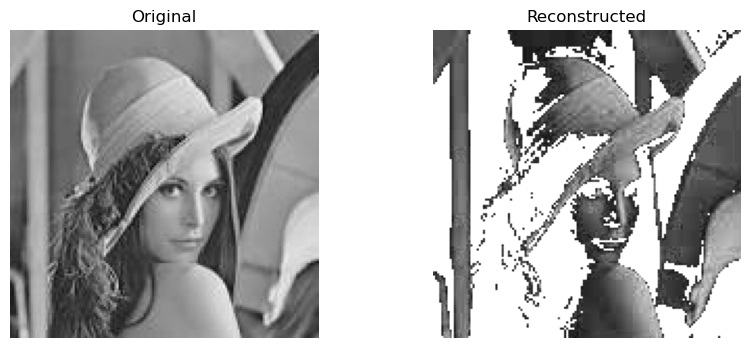

Compression Ratio: 2.65
PSNR: 30.30 dB


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict, Counter
import math

# ------------------ DCT/IDCT using matrix multiplication ------------------

def create_dct_matrix(N):
    dct_matrix = np.zeros((N, N))
    for k in range(N):
        for n in range(N):
            if k == 0:
                dct_matrix[k, n] = 1 / np.sqrt(N)
            else:
                dct_matrix[k, n] = np.sqrt(2 / N) * np.cos(((2 * n + 1) * k * np.pi) / (2 * N))
    return dct_matrix

def dct2(block, dct_mat):
    return dct_mat @ block @ dct_mat.T

def idct2(block, dct_mat):
    return dct_mat.T @ block @ dct_mat

# ------------------ Quantization ------------------

def quantize(block, scalar):
    return np.round(block / scalar).astype(np.int32)

def dequantize(block, scalar):
    return (block * scalar).astype(np.float32)

# ------------------ Huffman Coding ------------------

class Node:
    def __init__(self, symbol, freq):
        self.symbol = symbol
        self.freq = freq
        self.left = None
        self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(freqs):
    heap = [Node(sym, freq) for sym, freq in freqs.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        n1 = heapq.heappop(heap)
        n2 = heapq.heappop(heap)
        merged = Node(None, n1.freq + n2.freq)
        merged.left = n1
        merged.right = n2
        heapq.heappush(heap, merged)
    return heap[0]

def build_codes(node, prefix='', code_map={}):
    if node is None:
        return
    if node.symbol is not None:
        code_map[node.symbol] = prefix
    build_codes(node.left, prefix + '0', code_map)
    build_codes(node.right, prefix + '1', code_map)
    return code_map

def huffman_encode(data):
    flat = data.flatten()
    freqs = Counter(flat)
    root = build_huffman_tree(freqs)
    code_map = build_codes(root)
    encoded = ''.join(code_map[x] for x in flat)
    return encoded, code_map, flat.shape

def huffman_decode(encoded, code_map, shape):
    reverse_map = {v: k for k, v in code_map.items()}
    decoded = []
    current = ''
    for bit in encoded:
        current += bit
        if current in reverse_map:
            decoded.append(reverse_map[current])
            current = ''
    return np.array(decoded).reshape(shape)

# ------------------ PSNR ------------------

def compute_psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# ------------------ Main Pipeline ------------------

def jpeg_like_compression(image_path, block_size=8, quant_scalar=20):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape

    # Padding
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='constant')

    dct_mat = create_dct_matrix(block_size)

    blocks = []
    for i in range(0, padded.shape[0], block_size):
        for j in range(0, padded.shape[1], block_size):
            block = padded[i:i+block_size, j:j+block_size] - 128  # shift
            dct_block = dct2(block, dct_mat)
            q_block = quantize(dct_block, quant_scalar)
            blocks.append(q_block)

    # Flatten & Huffman encode
    all_data = np.concatenate([blk.flatten() for blk in blocks])
    encoded, code_map, shape = huffman_encode(all_data)

    # Compression Ratio
    original_bits = padded.size * 8
    compressed_bits = len(encoded)
    cr = original_bits / compressed_bits

    # Huffman decode
    decoded_data = huffman_decode(encoded, code_map, all_data.shape)
    decoded_blocks = decoded_data.reshape(-1, block_size, block_size)

    # Inverse DCT
    idx = 0
    reconstructed = np.zeros_like(padded, dtype=np.uint8)
    for i in range(0, padded.shape[0], block_size):
        for j in range(0, padded.shape[1], block_size):
            deq = dequantize(decoded_blocks[idx], quant_scalar)
            block = idct2(deq, dct_mat) + 128
            reconstructed[i:i+block_size, j:j+block_size] = np.clip(block, 0, 255)
            idx += 1

    # Remove padding
    final_image = reconstructed[:h, :w]
    psnr = compute_psnr(img, final_image)

    # Display
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(final_image, cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

    plt.show()

    print(f"Compression Ratio: {cr:.2f}")
    print(f"PSNR: {psnr:.2f} dB")

# Run
jpeg_like_compression('D:\\Code\\Lenna.jpeg', block_size=8, quant_scalar=20)

3) Perform image sharpening on an image in frequency domain using 

i. Butterworth High pass filter of order 2 and order 4 (Use different cut off frequency D0 = 15, 30, 80)  
ii. Gaussian High pass filler (same cut-off frequency)  
iii. Obtain a sharpened image.

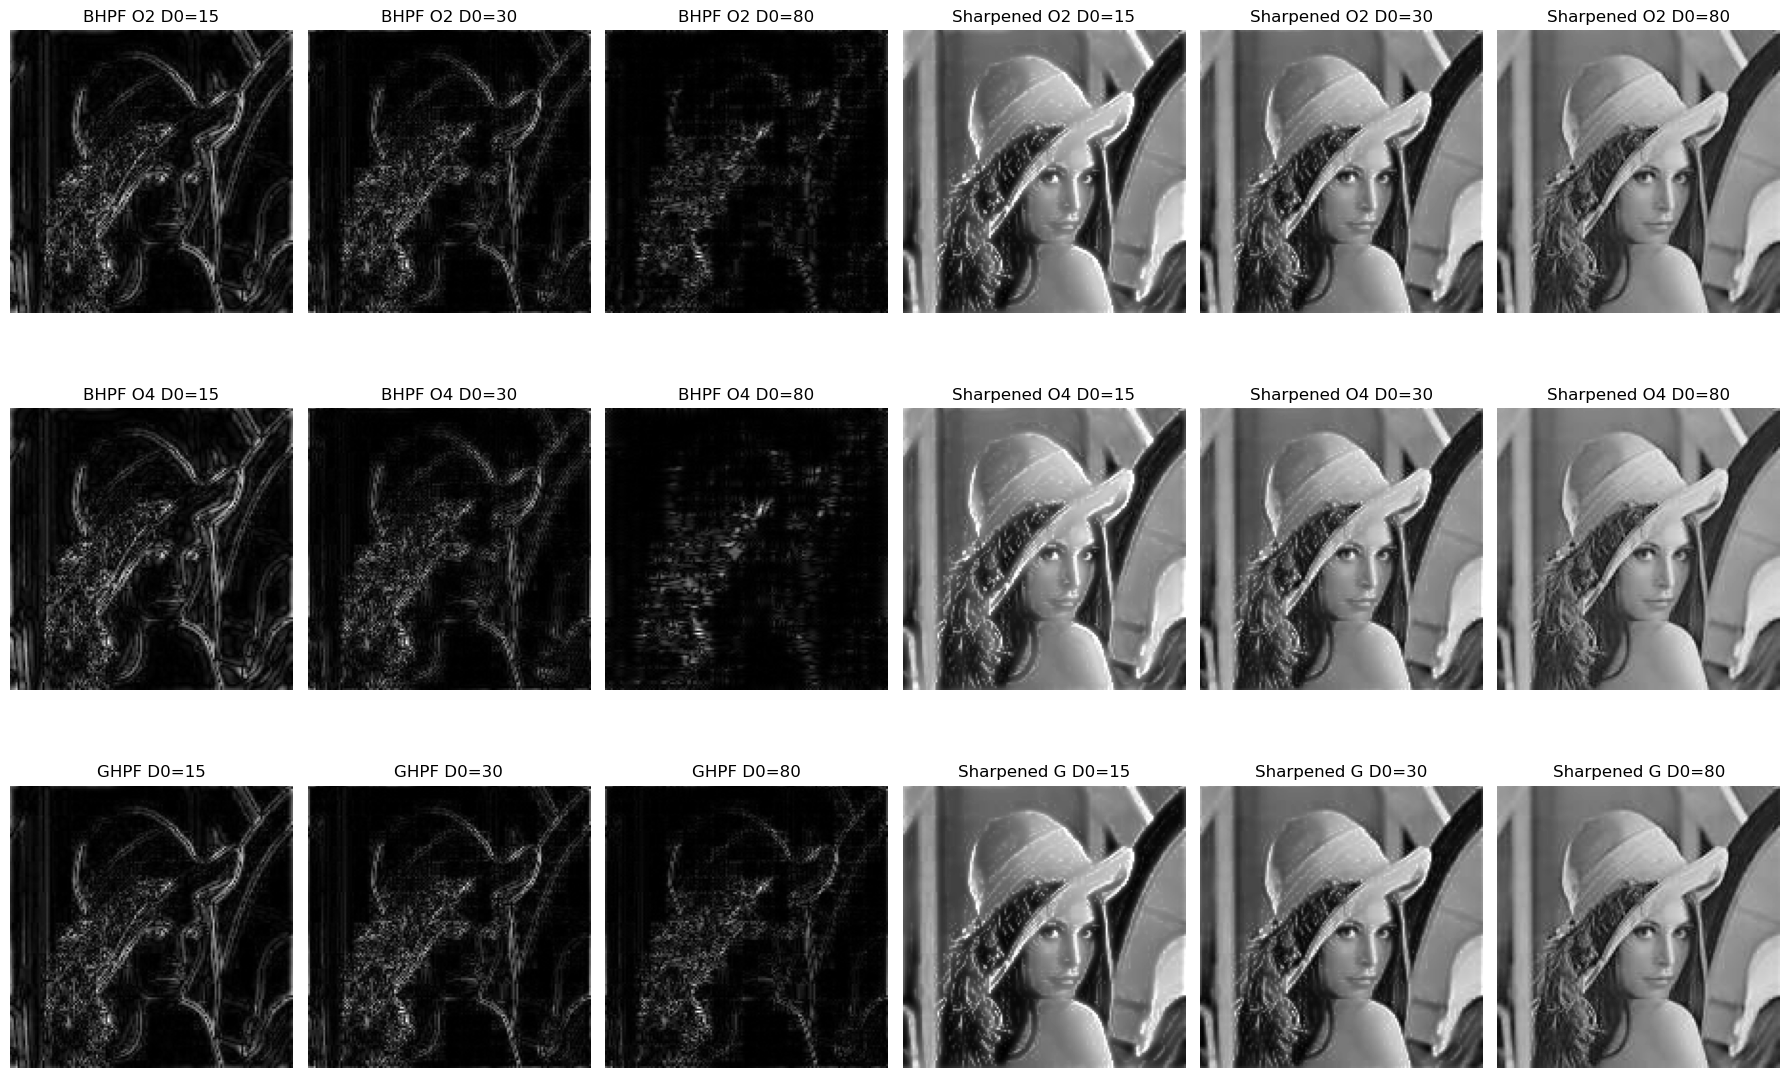

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fft_image(image):
    return np.fft.fftshift(np.fft.fft2(image))

def ifft_image(f_image):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(f_image)))

def distance_matrix(shape):
    rows, cols = shape
    center = (rows // 2, cols // 2)
    D = np.zeros((rows, cols))
    for u in range(rows):
        for v in range(cols):
            D[u, v] = np.sqrt((u - center[0])**2 + (v - center[1])**2)
    return D

def butterworth_high_pass(D, D0, order):
    return 1 / (1 + (D0 / (D + 1e-5))**(2 * order))

def gaussian_high_pass(D, D0):
    return 1 - np.exp(-(D**2) / (2 * D0**2))

def apply_filter(image, H):
    F = fft_image(image)
    G = F * H
    return ifft_image(G)

def sharpen_image(original, high_pass_result, alpha=1.0):
    sharpened = original + alpha * high_pass_result
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def main():
    img = cv2.imread("D:\\Code\\lenna.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float32)
    D = distance_matrix(img.shape)

    D0_values = [15, 30, 80]

    plt.figure(figsize=(18, 12))

    row = 0
    # Butterworth Order 2
    for i, D0 in enumerate(D0_values):
        H = butterworth_high_pass(D, D0, 2)
        filtered = apply_filter(img, H)
        sharpened = sharpen_image(img, filtered)
        plt.subplot(3, 6, row * 6 + i + 1)
        plt.imshow(filtered, cmap='gray')
        plt.title(f'BHPF O2 D0={D0}')
        plt.axis('off')
        plt.subplot(3, 6, row * 6 + i + 4)
        plt.imshow(sharpened, cmap='gray')
        plt.title(f'Sharpened O2 D0={D0}')
        plt.axis('off')
    row += 1

    # Butterworth Order 4
    for i, D0 in enumerate(D0_values):
        H = butterworth_high_pass(D, D0, 4)
        filtered = apply_filter(img, H)
        sharpened = sharpen_image(img, filtered)
        plt.subplot(3, 6, row * 6 + i + 1)
        plt.imshow(filtered, cmap='gray')
        plt.title(f'BHPF O4 D0={D0}')
        plt.axis('off')
        plt.subplot(3, 6, row * 6 + i + 4)
        plt.imshow(sharpened, cmap='gray')
        plt.title(f'Sharpened O4 D0={D0}')
        plt.axis('off')
    row += 1

    # Gaussian HPF
    for i, D0 in enumerate(D0_values):
        H = gaussian_high_pass(D, D0)
        filtered = apply_filter(img, H)
        sharpened = sharpen_image(img, filtered)
        plt.subplot(3, 6, row * 6 + i + 1)
        plt.imshow(filtered, cmap='gray')
        plt.title(f'GHPF D0={D0}')
        plt.axis('off')
        plt.subplot(3, 6, row * 6 + i + 4)
        plt.imshow(sharpened, cmap='gray')
        plt.title(f'Sharpened G D0={D0}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

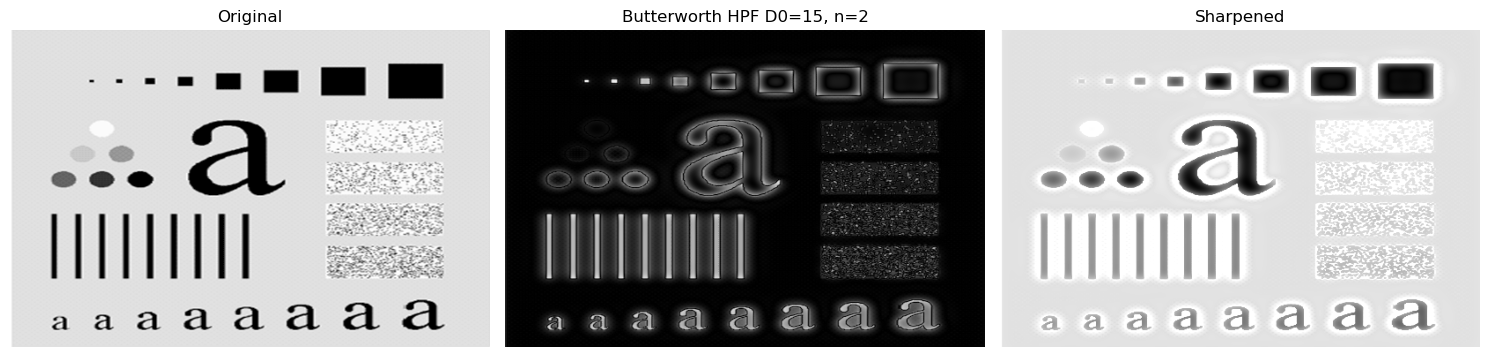

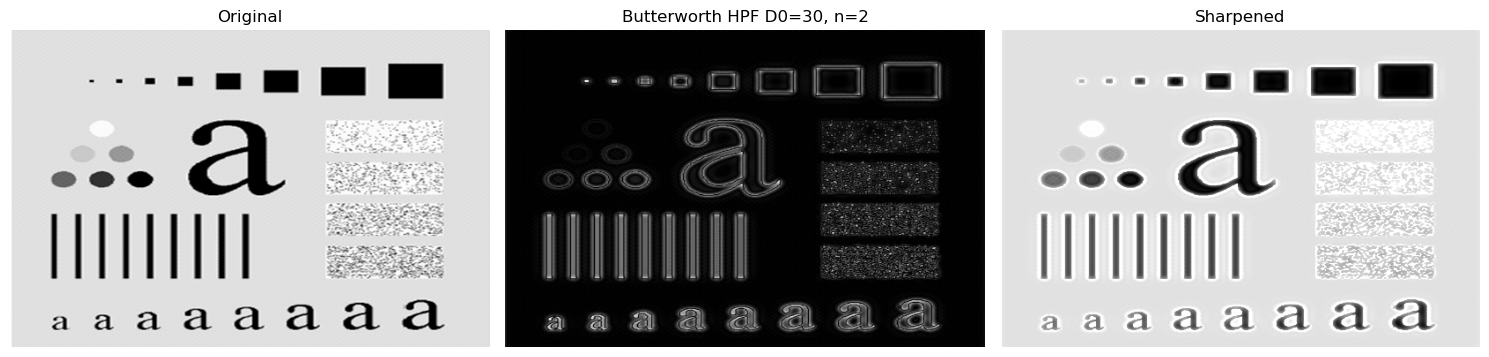

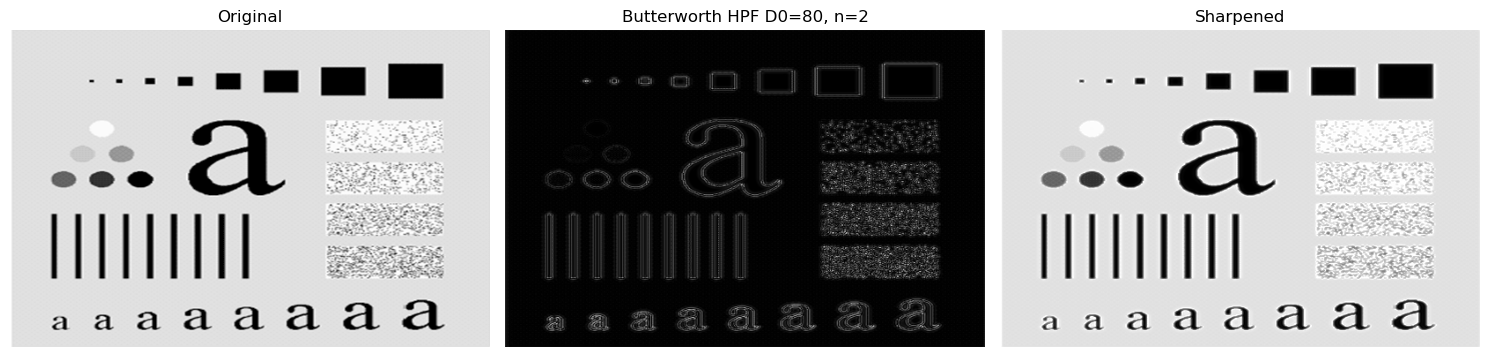

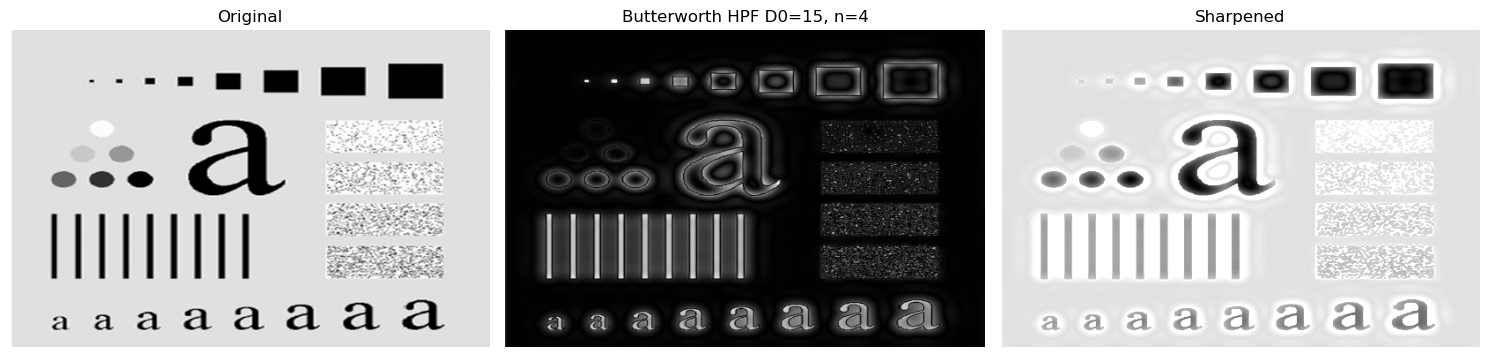

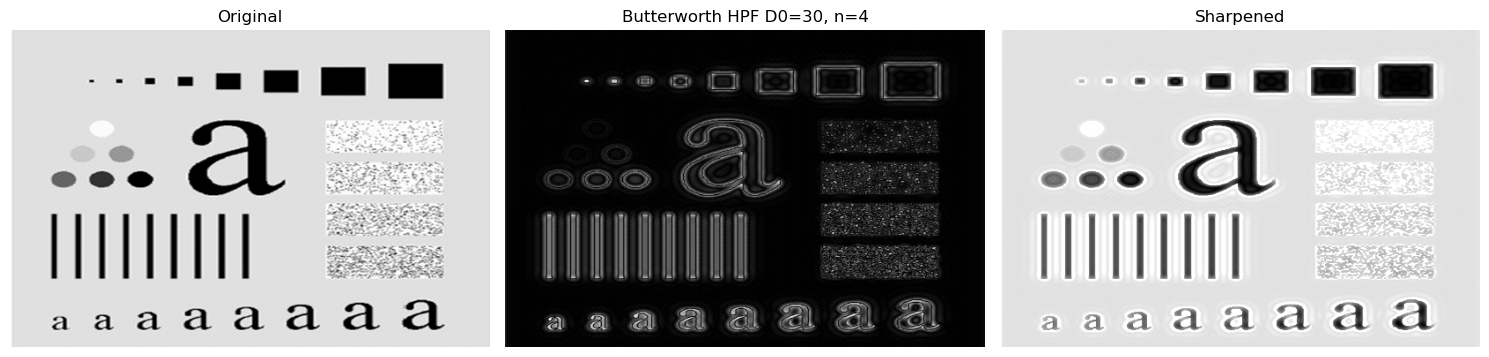

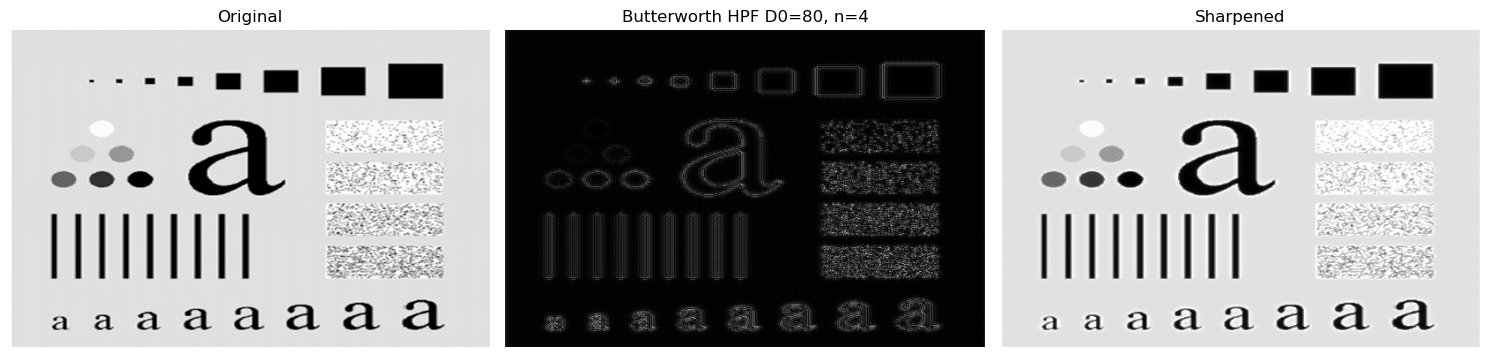

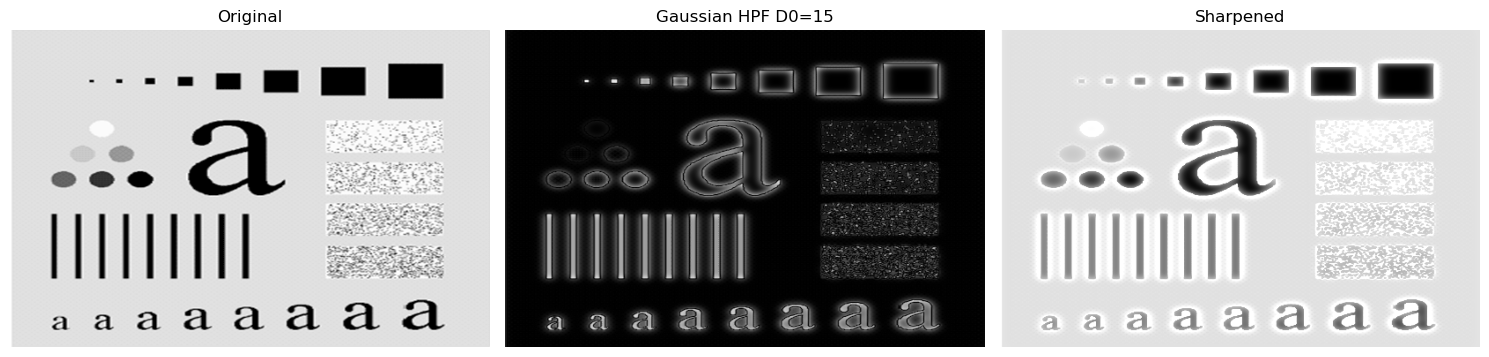

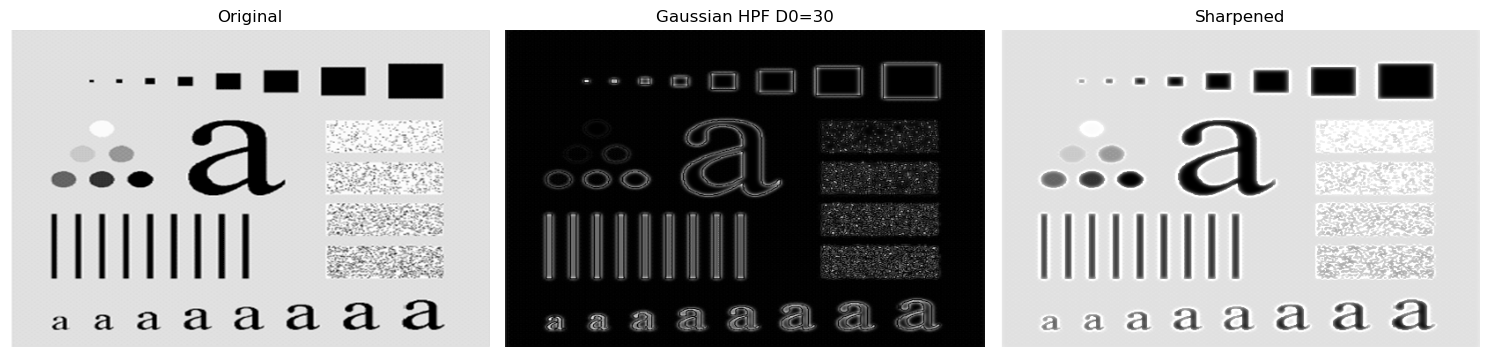

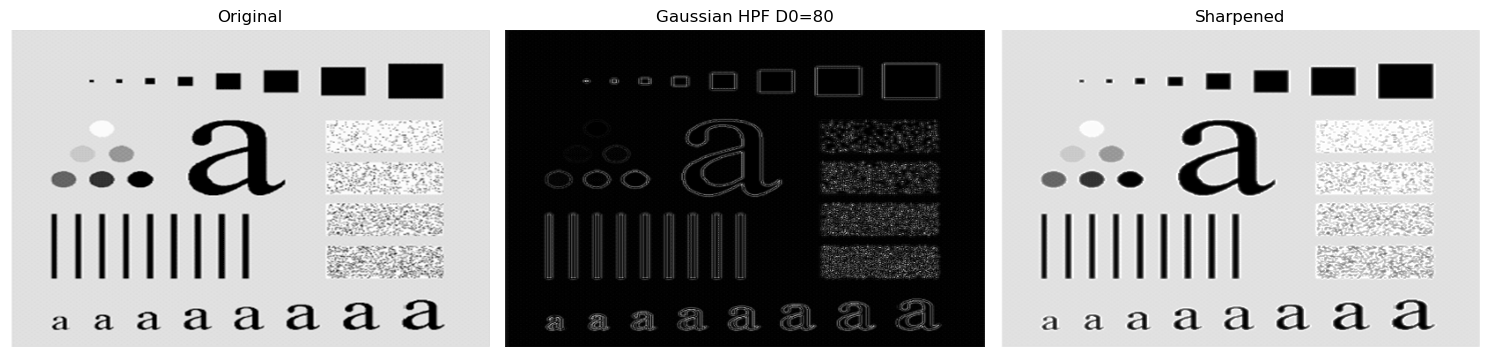

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def load_grayscale_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return img.astype(np.float32)

def fft_image(img):
    return np.fft.fftshift(np.fft.fft2(img))

def ifft_image(fshift):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(fshift)))

def butterworth_highpass(shape, D0, n):
    M, N = shape
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = 1 / (1 + (D0 / (D + 1e-5))**(2 * n))  # avoid divide-by-zero
    return H

def gaussian_highpass(shape, D0):
    M, N = shape
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = 1 - np.exp(-(D**2) / (2 * (D0**2)))
    return H

def sharpen_image(original, high_pass_result, alpha=1.0):
    return np.clip(original + alpha * high_pass_result, 0, 255)

def apply_filter(img, H):
    F = fft_image(img)
    F_filtered = F * H
    filtered_img = ifft_image(F_filtered)
    return filtered_img

def show_images(imgs, titles, cmap='gray'):
    plt.figure(figsize=(15, 5))
    for i in range(len(imgs)):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(imgs[i], cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Main process
image_path = 'D:\\Code\\test_img.png'  # replace with your image path
img = load_grayscale_image(image_path)
shape = img.shape

cutoff_freqs = [15, 30, 80]
orders = [2, 4]

for order in orders:
    for D0 in cutoff_freqs:
        H_butter = butterworth_highpass(shape, D0, order)
        hp_img = apply_filter(img, H_butter)
        sharp_img = sharpen_image(img, hp_img)
        show_images([img, hp_img, sharp_img],
                    [f'Original', f'Butterworth HPF D0={D0}, n={order}', 'Sharpened'])

for D0 in cutoff_freqs:
    H_gaussian = gaussian_highpass(shape, D0)
    hp_img = apply_filter(img, H_gaussian)
    sharp_img = sharpen_image(img, hp_img)
    show_images([img, hp_img, sharp_img],
                [f'Original', f'Gaussian HPF D0={D0}', 'Sharpened'])
